# CNN Image Classification


In [63]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 1: Unzip Dataset

In [64]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Copy of FruitinAmazon.zip"
extract_path = "dataset"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully.")
else:
    print("Dataset already extracted.")

Dataset already extracted.


In [65]:
def locate_dataset_dirs():
    for base, folders, _ in os.walk('.'):
        if 'train' in folders and 'test' in folders:
            train_path = os.path.join(base, 'train')
            test_path = os.path.join(base, 'test')
            print(f"Dataset located at: {base}")
            return train_path, test_path

    for base, folders, _ in os.walk('.'):
        if 'train' in folders:
            return os.path.join(base, 'train'), None

    return None, None


train_dir, test_dir = locate_dataset_dirs()

if train_dir and os.path.exists(train_dir):
    print(f"Train directory: {train_dir}")
else:
    print("Train directory not found after extraction.")
    print("Verify extracted folders and structure.")

if test_dir and os.path.exists(test_dir):
    print(f"Test directory: {test_dir}")
else:
    print("Test directory missing. Proceeding with validation split.")

%matplotlib inline
plt.style.use('seaborn-v0_8')
print("Environment ready. Continue with next steps.")

Dataset located at: ./drive/MyDrive/FruitinAmazon/FruitinAmazon
Train directory: ./drive/MyDrive/FruitinAmazon/FruitinAmazon/train
Test directory: ./drive/MyDrive/FruitinAmazon/FruitinAmazon/test
Environment ready. Continue with next steps.


In [66]:
from PIL import Image

removed = 0

for root, _, files in os.walk(train_dir):
    for f in files:
        file_path = os.path.join(root, f)
        try:
            Image.open(file_path).verify()
        except:
            os.remove(file_path)
            removed += 1

print(f"Removed corrupted images: {removed}")

Removed corrupted images: 0


## Step 2: Imports

In [67]:
import os
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report

## Step 3: Visualize Dataset

Total classes: 6 -> ['tucuma', 'cupuacu', 'guarana', 'acai', 'graviola', 'pupunha']


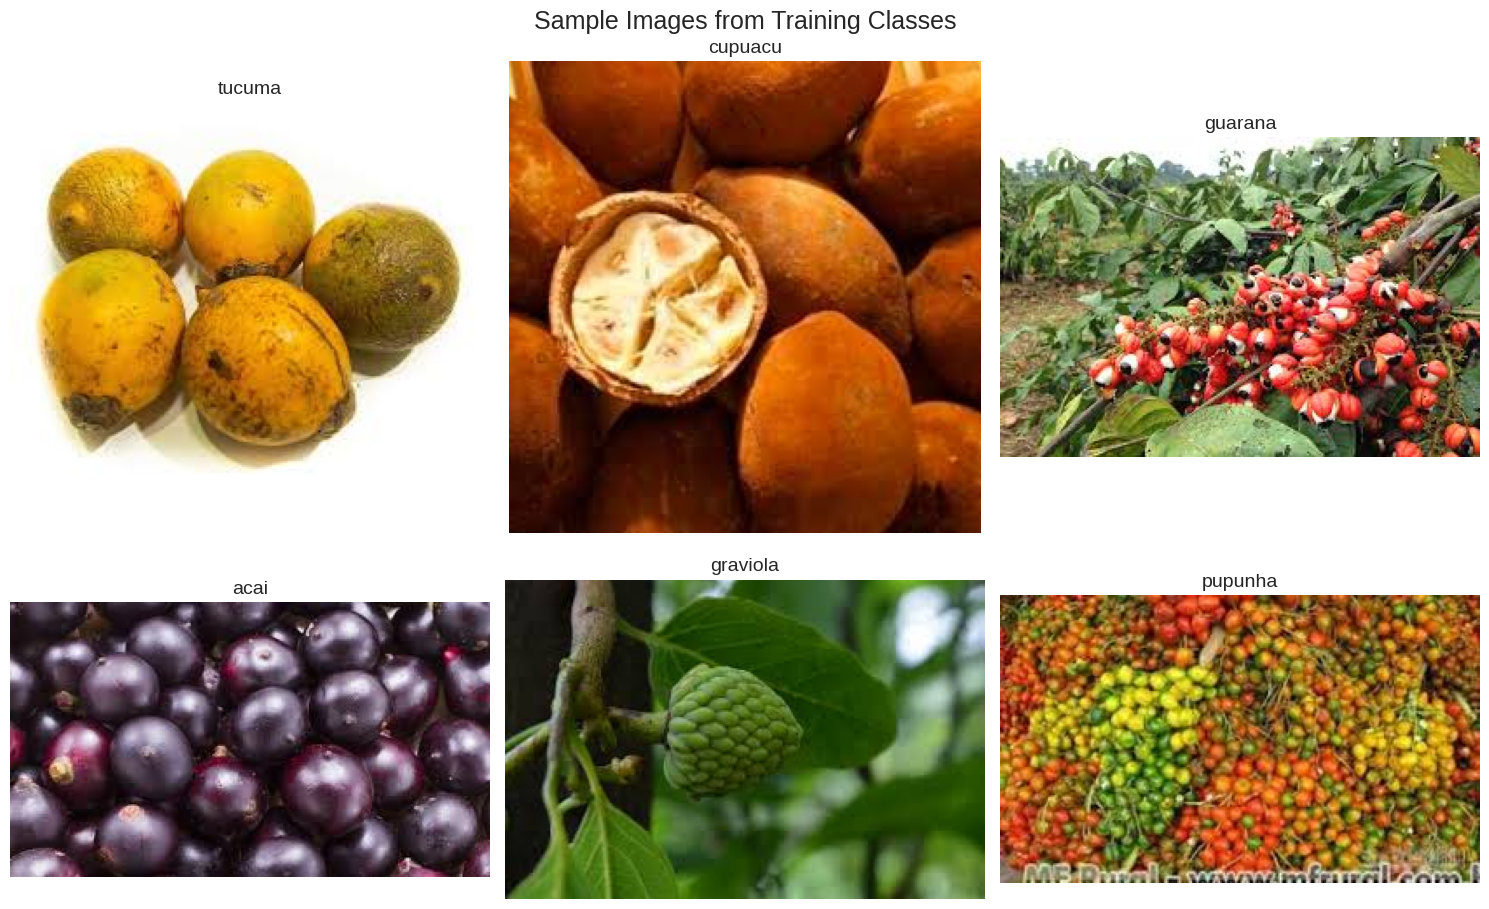

In [68]:
classes = [folder for folder in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, folder))]
print(f"Total classes: {len(classes)} -> {classes}")

sample_images = []
sample_labels = []

for category in classes:
    path = os.path.join(train_dir, category)
    files = [img for img in os.listdir(path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if files:
        selected = random.choice(files)
        full_path = os.path.join(path, selected)
        sample_images.append(full_path)
        sample_labels.append(category)

fig, grid = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Sample Images from Training Classes', fontsize=18)

for idx, axis in enumerate(grid.flat):
    if idx < len(sample_images):
        image = Image.open(sample_images[idx])
        axis.imshow(image)
        axis.set_title(sample_labels[idx], fontsize=14)
        axis.axis('off')

plt.tight_layout()
plt.show()

## Step 4: Remove Corrupted Images

In [69]:
bad_images = []

for cls in class_names:
    cls_path = os.path.join(train_path, cls)

    for file in os.listdir(cls_path):
        file_path = os.path.join(cls_path, file)

        try:
            with Image.open(file_path) as img:
                img.verify()
        except Exception:
            bad_images.append(file_path)
            os.remove(file_path)
            print("Removed:", file_path)

if not bad_images:
    print("No corrupted images found.")

No corrupted images found.


## Step 5: Load Dataset

In [70]:
img_height = 128
img_width = 128
batch_size = 16
val_split = 0.2

normalizer = tf.keras.layers.Rescaling(1.0 / 255)

train_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=val_split,
    subset='training',
    seed=123
)

val_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=val_split,
    subset='validation',
    seed=123
)

test_raw = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

class_names = train_raw.class_names
total_classes = len(class_names)

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05)
])

train_ds = train_raw.map(lambda x, y: (augmentation(normalizer(x)), y))
val_ds = val_raw.map(lambda x, y: (normalizer(x), y))
test_ds = test_raw.map(lambda x, y: (normalizer(x), y))

print(f"Classes: {class_names}")
print(f"Train samples: {len(train_ds) * batch_size}")
print(f"Validation samples: {len(val_ds) * batch_size}")
print(f"Test samples: {len(test_ds) * batch_size}")
print("Datasets ready and normalized.")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Train samples: 80
Validation samples: 32
Test samples: 32
Datasets ready and normalized.


## Step 6: Build CNN Model

In [71]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        padding='same',
        activation='relu',
        input_shape=(img_height, img_width, 3)
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        padding='same',
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation='relu'),
tf.keras.layers.Dropout(0.3),

tf.keras.layers.Dense(128, activation='relu'),
tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(total_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │     4,194,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,222,854 (16.11 MB)

 Trainable params: 4,222,854 (16.11 MB)

 Non-trainable params: 0 (0.00 B)

## Step 7: Compile Model

In [72]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ckpt = ModelCheckpoint(
    filepath='best_fruit_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[ckpt, early]
)

Epoch 1/250


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.1306 - loss: 2.0301
Epoch 1: val_loss improved from None to 2.09022, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 547ms/step - accuracy: 0.1111 - loss: 2.0530 - val_accuracy: 0.0000e+00 - val_loss: 2.0902
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.2795 - loss: 1.7285
Epoch 2: val_loss improved from 2.09022 to 1.94214, saving model to best_fruit_model.h5



Epoch 2: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 471ms/step - accuracy: 0.2361 - loss: 1.7336 - val_accuracy: 0.0556 - val_loss: 1.9421
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.2194 - loss: 1.7941
Epoch 3: val_loss improved from 1.94214 to 1.70522, saving model to best_fruit_model.h5



Epoch 3: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 504ms/step - accuracy: 0.2639 - loss: 1.7625 - val_accuracy: 0.1111 - val_loss: 1.7052
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.3170 - loss: 1.6445
Epoch 4: val_loss improved from 1.70522 to 1.58608, saving model to best_fruit_model.h5


...


Epoch 25: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 475ms/step - accuracy: 0.7917 - loss: 0.5350 - val_accuracy: 0.8889 - val_loss: 0.2424
Epoch 26/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.9392 - loss: 0.2324
Epoch 26: val_loss did not improve from 0.24241
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 449ms/step - accuracy: 0.9306 - loss: 0.2311 - val_accuracy: 0.7778 - val_loss: 0.7189
Epoch 27/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.8569 - loss: 0.4342
Epoch 27: val_loss did not improve from 0.24241
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 679ms/step - accuracy: 0.8472 - loss: 0.4465 - val_accuracy: 0.7222 - val_loss: 0.6746
Epoch 28/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.9111 - loss: 0.3751
Epoch 28: val_loss improved from 0.24241 to 0.23803, saving model to best_fruit_model.h5



Epoch 28: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 816ms/step - accuracy: 0.8889 - loss: 0.3854 - val_accuracy: 0.8889 - val_loss: 0.2380
Epoch 29/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.9674 - loss: 0.1565
Epoch 29: val_loss did not improve from 0.23803
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 440ms/step - accuracy: 0.9722 - loss: 0.1681 - val_accuracy: 0.8333 - val_loss: 0.3683
Epoch 30/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.9549 - loss: 0.1645
Epoch 30: val_loss did not improve from 0.23803
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 440ms/step - accuracy: 0.9306 - loss: 0.2450 - val_accuracy: 0.8333 - val_loss: 0.6352
Epoch 31/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.9090 - loss: 0.3304
Epoch 31: val_loss did not improve from 0.23803
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 436ms/step - accuracy: 0.8889 - loss: 0.3727 - val_accuracy: 0.7778 - val_loss: 0.4278
Epoch 32/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.7948 - loss: 0.5


Epoch 39: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 500ms/step - accuracy: 0.8750 - loss: 0.3749 - val_accuracy: 0.8889 - val_loss: 0.2233
Epoch 40/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.9840 - loss: 0.1347
Epoch 40: val_loss did not improve from 0.22333
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 447ms/step - accuracy: 0.9722 - loss: 0.1193 - val_accuracy: 0.8333 - val_loss: 0.4347
Epoch 41/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.9306 - loss: 0.2872
Epoch 41: val_loss did not improve from 0.22333
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 715ms/step - accuracy: 0.9444 - loss: 0.2015 - val_accuracy: 0.8333 - val_loss: 0.4121
Epoch 42/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.9181 - loss: 0.1882
Epoch 42: val_loss did not improve from 0.22333
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 578ms/step - accuracy: 0.9028 - loss: 0.2269 - val_accuracy: 0.8333 - val_loss: 0.4009
Epoch 43/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.9392 - loss: 0.1


Epoch 56: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 704ms/step - accuracy: 0.9583 - loss: 0.1565 - val_accuracy: 0.8889 - val_loss: 0.2110
Epoch 57/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.9385 - loss: 0.1375
Epoch 57: val_loss did not improve from 0.21095
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 624ms/step - accuracy: 0.9583 - loss: 0.1288 - val_accuracy: 0.8889 - val_loss: 0.2179
Epoch 58/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.9358 - loss: 0.1074
Epoch 58: val_loss did not improve from 0.21095
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 465ms/step - accuracy: 0.9444 - loss: 0.1069 - val_accuracy: 0.8333 - val_loss: 0.5999
Epoch 59/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9684 - loss: 0.2112
Epoch 59: val_loss did not improve from 0.21095
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 455ms/step - accuracy: 0.9722 - loss: 0.1500 - val_accuracy: 0.8333 - val_loss: 0.7214
Epoch 60/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.9677 - loss: 0.0


Epoch 64: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 500ms/step - accuracy: 0.9722 - loss: 0.1281 - val_accuracy: 0.9444 - val_loss: 0.1672
Epoch 65/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.9521 - loss: 0.1401
Epoch 65: val_loss did not improve from 0.16715
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 475ms/step - accuracy: 0.9583 - loss: 0.1321 - val_accuracy: 0.8889 - val_loss: 0.4158
Epoch 66/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.9306 - loss: 0.2379
Epoch 66: val_loss did not improve from 0.16715
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 787ms/step - accuracy: 0.9028 - loss: 0.2737 - val_accuracy: 0.8333 - val_loss: 0.5453
Epoch 67/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9389 - loss: 0.1425
Epoch 67: val_loss did not improve from 0.16715
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 457ms/step - accuracy: 0.9444 - loss: 0.1324 - val_accuracy: 0.8889 - val_loss: 0.3567
Epoch 68/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 1.0000 - loss: 0.0

## Step 8: Evaluate Model

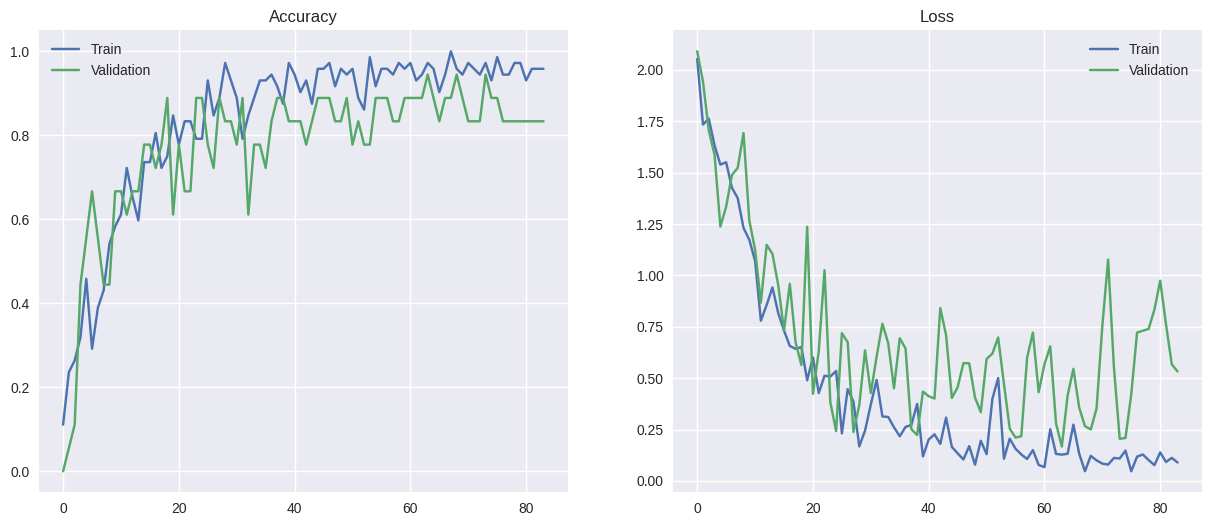

In [76]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history.get('accuracy'), label='Train')
plt.plot(history.history.get('val_accuracy'), label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history.get('loss'), label='Train')
plt.plot(history.history.get('val_loss'), label='Validation')
plt.title('Loss')
plt.legend()

plt.show()

## Step 9: Evaluate Model

In [74]:
model.save('fruit_classifier_final.h5')

print("Model saved as fruit_classifier_final.h5")

reloaded_model = tf.keras.models.load_model('fruit_classifier_final.h5')

eval_loss, eval_acc = reloaded_model.evaluate(test_ds)

print(f"Loaded model Test Accuracy: {eval_acc:.4f}")

Model saved as fruit_classifier_final.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.8000 - loss: 0.6223
Loaded model Test Accuracy: 0.8000


## Step 10: Report

In [75]:
preds = model.predict(test_ds)
pred_labels = np.argmax(preds, axis=1)

actual_labels = []
for _, lbl in test_ds:
    actual_labels.extend(lbl.numpy())

actual_labels = np.array(actual_labels)

print("=" * 70)
print("CLASSIFICATION REPORT (TEST SET)")
print("=" * 70)

print(
    classification_report(
        actual_labels,
        pred_labels,
        target_names=class_names,
        digits=2
    )
)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

        acai       0.83      1.00      0.91         5
     cupuacu       0.75      0.60      0.67         5
    graviola       0.62      1.00      0.77         5
     guarana       0.80      0.80      0.80         5
     pupunha       1.00      0.80      0.89         5
      tucuma       1.00      0.60      0.75         5

    accuracy                           0.80        30
   macro avg       0.83      0.80      0.80        30
weighted avg       0.83      0.80      0.80        30

